In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv("credit_card_fraud_dataset.csv")
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
df=df.drop('TransactionID',axis=1)

In [5]:
df.head()

,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [6]:
df['TransactionDate']=pd.to_datetime(df['TransactionDate'])
df["hours"]=df['TransactionDate'].dt.hour
df["day"]=df["TransactionDate"].dt.day
df["day_of_week"]=df["TransactionDate"].dt.day_name()
df["month"]=df["TransactionDate"].dt.month


In [7]:
df.count()

TransactionDate    100000
Amount             100000
MerchantID         100000
TransactionType    100000
Location           100000
IsFraud            100000
hours              100000
day                100000
day_of_week        100000
month              100000
dtype: int64

In [8]:
df.describe()

,TransactionDate,Amount,MerchantID,IsFraud,hours,day,month
count,100000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,2024-04-21 13:06:09.973745,2497.092666,501.676070,0.010000,11.50084,15.782220,6.516240
min,2023-10-21 09:28:35.824439,1.050000,1.000000,0.000000,0.00000,1.000000,1.000000
25%,2024-01-20 23:18:20.586056,1247.955000,252.000000,0.000000,6.00000,8.000000,4.000000
50%,2024-04-21 13:39:35.701439,2496.500000,503.000000,0.000000,12.00000,16.000000,7.000000
75%,2024-07-21 22:28:05.702624,3743.592500,753.000000,0.000000,17.00000,23.000000,10.000000
max,2024-10-21 09:20:35.961088,4999.770000,1000.000000,1.000000,23.00000,31.000000,12.000000
std,NaN,1442.415999,288.715868,0.099499,6.91768,8.813795,3.448248


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionDate  100000 non-null  datetime64[us]
 1   Amount           100000 non-null  float64       
 2   MerchantID       100000 non-null  int64         
 3   TransactionType  100000 non-null  str           
 4   Location         100000 non-null  str           
 5   IsFraud          100000 non-null  int64         
 6   hours            100000 non-null  int32         
 7   day              100000 non-null  int32         
 8   day_of_week      100000 non-null  str           
 9   month            100000 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(3), int64(2), str(3)
memory usage: 6.5 MB


In [10]:
df['MerchantID'].value_counts()

MerchantID
461    149
188    134
192    129
517    128
820    126
      ... 
119     75
936     74
968     73
635     71
512     69
Name: count, Length: 1000, dtype: int64

In [11]:
df.head(10)

,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,hours,day,day_of_week,month
0,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,14,3,Wednesday,4
1,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,13,19,Tuesday,3
2,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,10,8,Monday,1
3,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,23,13,Saturday,4
4,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,18,12,Friday,7
5,2024-08-30 01:52:35.462867,3086.22,302,purchase,New York,0,1,30,Friday,8
6,2024-01-02 11:31:35.462875,1466.90,902,refund,Philadelphia,0,11,2,Tuesday,1
7,2024-05-12 12:25:35.462885,917.21,266,purchase,New York,0,12,12,Sunday,5
8,2023-11-16 02:20:35.462894,1625.73,32,refund,Chicago,0,2,16,Thursday,11
9,2023-10-24 06:51:35.462901,662.07,193,purchase,Dallas,0,6,24,Tuesday,10


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionDate  100000 non-null  datetime64[us]
 1   Amount           100000 non-null  float64       
 2   MerchantID       100000 non-null  int64         
 3   TransactionType  100000 non-null  str           
 4   Location         100000 non-null  str           
 5   IsFraud          100000 non-null  int64         
 6   hours            100000 non-null  int32         
 7   day              100000 non-null  int32         
 8   day_of_week      100000 non-null  str           
 9   month            100000 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(3), int64(2), str(3)
memory usage: 6.5 MB


In [13]:
df=df.drop('TransactionDate',axis=1)
df.head()

,Amount,MerchantID,TransactionType,Location,IsFraud,hours,day,day_of_week,month
0,4189.27,688,refund,San Antonio,0,14,3,Wednesday,4
1,2659.71,109,refund,Dallas,0,13,19,Tuesday,3
2,784.00,394,purchase,New York,0,10,8,Monday,1
3,3514.40,944,purchase,Philadelphia,0,23,13,Saturday,4
4,369.07,475,purchase,Phoenix,0,18,12,Friday,7


In [14]:
df=pd.get_dummies(df,columns=['TransactionType','Location','day_of_week'])
df.head()

,Amount,MerchantID,IsFraud,hours,day,month,TransactionType_purchase,TransactionType_refund,Location_Chicago,Location_Dallas,...,Location_San Antonio,Location_San Diego,Location_San Jose,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,4189.27,688,0,14,3,4,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
1,2659.71,109,0,13,19,3,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False
2,784.00,394,0,10,8,1,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,3514.40,944,0,23,13,4,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,369.07,475,0,18,12,7,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [15]:
x=df.drop('IsFraud',axis=1)
y=df['IsFraud']

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
scalar=MinMaxScaler()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=5)
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

In [17]:
x_train_scaled_df=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled_df=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [18]:
x_train_scaled_df.head()

,Amount,MerchantID,hours,day,month,TransactionType_purchase,TransactionType_refund,Location_Chicago,Location_Dallas,Location_Houston,...,Location_San Antonio,Location_San Diego,Location_San Jose,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0.548416,0.722723,0.000000,0.000000,1.000000,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.821023,0.259259,0.826087,0.933333,0.727273,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.230495,0.218218,0.391304,0.100000,0.454545,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.153306,0.932933,0.652174,0.133333,0.181818,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.643678,0.696697,0.739130,0.800000,0.636364,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
ann=keras.Sequential([
  keras.layers.Dense(24,input_shape=(24,),activation='relu'),
  keras.layers.Dense(12,activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
])

ann.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
ann.fit(x_train_scaled_df,y_train,epochs=5)


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9897 - loss: 0.0622
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9898 - loss: 0.0573
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9898 - loss: 0.0570
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9898 - loss: 0.0569
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9898 - loss: 0.0568


In [20]:
ann.evaluate(x_test_scaled_df,y_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9906 - loss: 0.0539


[0.05389491468667984, 0.9905999898910522]

In [21]:
yp=ann.predict(x_test_scaled_df)
yp[:10]

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step


array([[0.01273428],
       [0.02112893],
       [0.00674194],
       [0.03971594],
       [0.00703773],
       [0.00851016],
       [0.01415669],
       [0.01680319],
       [0.01274851],
       [0.00647879]], dtype=float32)

In [22]:
y_pred=[]
for ele in yp:
  if ele>=0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

In [23]:
y_pred[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19812
           1       0.00      0.00      0.00       188

    accuracy                           0.99     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.99      0.99     20000



c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Text(95.83333333333333, 0.5, 'actual')

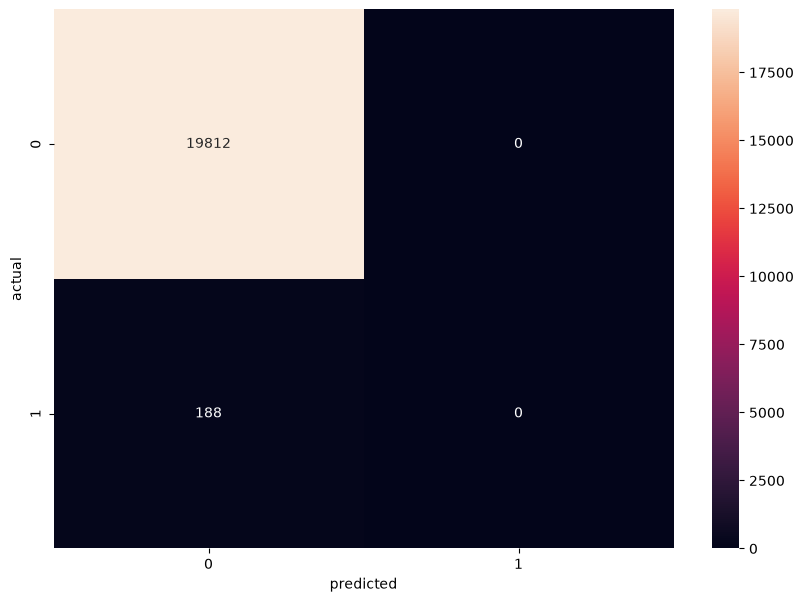

In [25]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot= True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')

In [26]:
y_train.value_counts()

IsFraud
0    79188
1      812
Name: count, dtype: int64

In [27]:
import pandas as pd

train_data = pd.concat([x_train, y_train], axis=1)

# 2. Separate majority (0) and minority (1) classes
df_class_0 = train_data[train_data["IsFraud"] == 0]
df_class_1 = train_data[train_data["IsFraud"] == 1]



In [28]:
df_class_0_under=df_class_0.sample(n=len(df_class_1),random_state=42)
df_under=pd.concat([df_class_0_under,df_class_1],axis=0)
df_under=df_under.sample(frac=1,random_state=42)

In [29]:
x_train_under=df_under.drop("IsFraud",axis=1)
y_train_under=df_under["IsFraud"]

In [30]:
print(y_train_under.shape)

(1624,)


In [31]:
print(x_train_under.shape)

(1624, 24)


In [32]:
x_train_under.shape

(1624, 24)

In [33]:
ann=keras.Sequential([
  keras.layers.Dense(24,input_shape=(24,),activation='relu'),
  keras.layers.Dense(12,activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
])

ann.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
ann.fit(x_train_under,y_train_under,epochs=5)


Epoch 1/5


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4729 - loss: 17.0046  
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5025 - loss: 2.6461
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4865 - loss: 1.7417
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5043 - loss: 1.1852
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5105 - loss: 1.0260


In [34]:
yp=ann.predict(x_test)
yp[:5]

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 770us/step


array([[0.83188784],
       [0.50548303],
       [0.94542885],
       [0.7599026 ],
       [0.7711492 ]], dtype=float32)

In [35]:
x_train_under.shape

(1624, 24)

In [36]:
y_pred = (ann.predict(x_test) > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step


In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      0.16      0.28     19812
           1       0.01      0.81      0.02       188

    accuracy                           0.17     20000
   macro avg       0.50      0.49      0.15     20000
weighted avg       0.98      0.17      0.28     20000



Text(95.83333333333333, 0.5, 'actual')

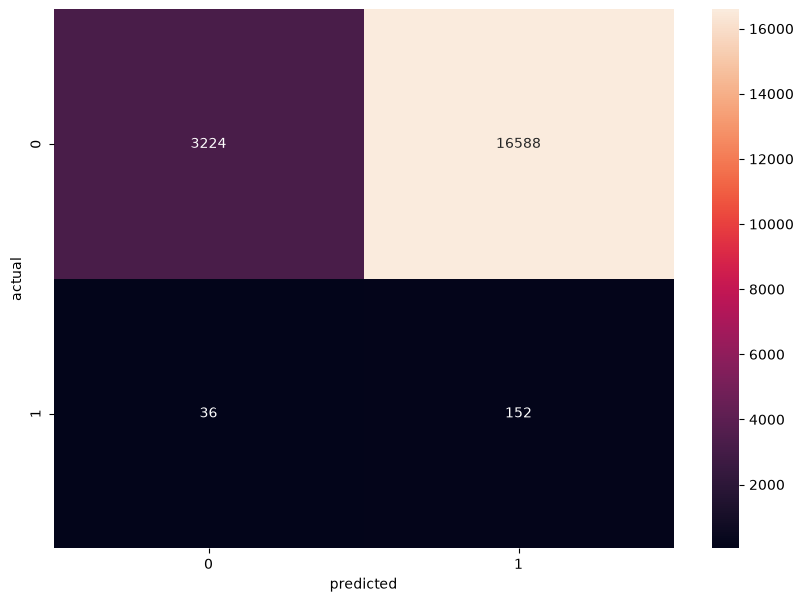

In [38]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot= True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')

In [49]:
#over sampling
from sklearn.model_selection import train_test_split

x = df.drop("IsFraud", axis=1)
y = df["IsFraud"]


x_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
train_data = pd.concat(
    [x_train, y_train],
    axis=1
)

In [51]:
df_class_0 = train_data[train_data["IsFraud"] == 0]

df_class_1 = train_data[train_data["IsFraud"] == 1]

In [52]:
df_class_1_over = df_class_1.sample(
    len(df_class_0),
    replace=True,
    random_state=42
)

In [53]:
df_train_over = pd.concat(
    [df_class_0, df_class_1_over],
    axis=0
)

In [54]:
df_train_over = df_train_over.sample(
    frac=1,
    random_state=42
)

In [55]:
X_train_over = df_train_over.drop(
    "IsFraud",
    axis=1
)

y_train_over = df_train_over["IsFraud"]

In [56]:
print(y_train_over.value_counts())

IsFraud
0    79200
1    79200
Name: count, dtype: int64


In [57]:
ann=keras.Sequential([
  keras.layers.Dense(24,input_shape=(24,),activation='relu'),
  keras.layers.Dense(12,activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
])

ann.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
ann.fit(X_train_over,y_train_over,epochs=10)


Epoch 1/10


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4950/4950 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.5158 - loss: 0.9953
Epoch 2/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5220 - loss: 0.9109
Epoch 3/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5236 - loss: 0.8783
Epoch 4/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5304 - loss: 0.8406
Epoch 5/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5323 - loss: 0.8182
Epoch 6/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.5391 - loss: 0.7876
Epoch 7/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5392 - loss: 0.7645
Epoch 8/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5387 - loss: 0.7491
Epoch 9/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5422 - loss: 0.7338
Epoch 10/10
4950/4950 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5425 - loss: 0.7192


In [58]:
y_pred = (ann.predict(X_test) > 0.5).astype(int)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 876us/step


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.16      0.27     19800
           1       0.01      0.83      0.02       200

    accuracy                           0.16     20000
   macro avg       0.50      0.49      0.15     20000
weighted avg       0.98      0.16      0.27     20000



Text(95.83333333333333, 0.5, 'actual')

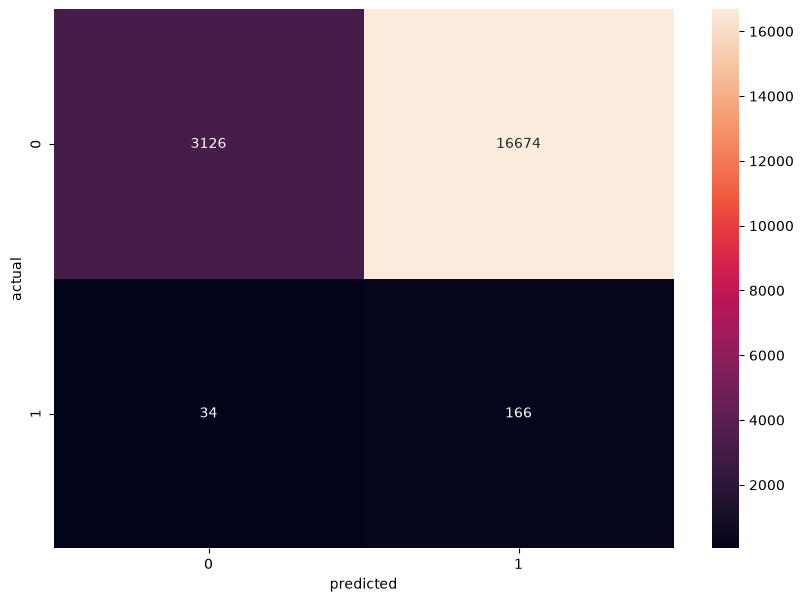

In [60]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot= True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')

In [69]:
x_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [75]:
ann=keras.Sequential([
  keras.layers.Dense(24,input_shape=(24,),activation='relu'),
  keras.layers.Dense(12,activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
])

ann.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
ann.fit(x_train_smote,y_train_smote,batch_size=32)


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4950/4950 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.7512 - loss: 0.7802


In [76]:
y_pred = (ann.predict(X_test)>0.5).astype(int)

print(classification_report(y_test,y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.02      0.02      0.02       200

    accuracy                           0.98     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.98      0.98      0.98     20000



Text(95.83333333333333, 0.5, 'actual')

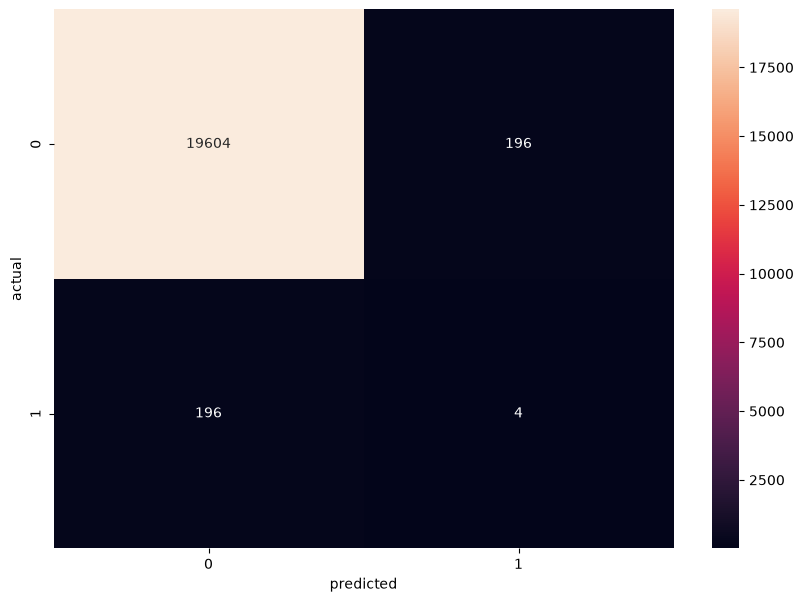

In [78]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot= True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')

In [79]:
print(y_test.value_counts())
print(y_pred.shape)

IsFraud
0    19800
1      200
Name: count, dtype: int64
(20000, 1)
